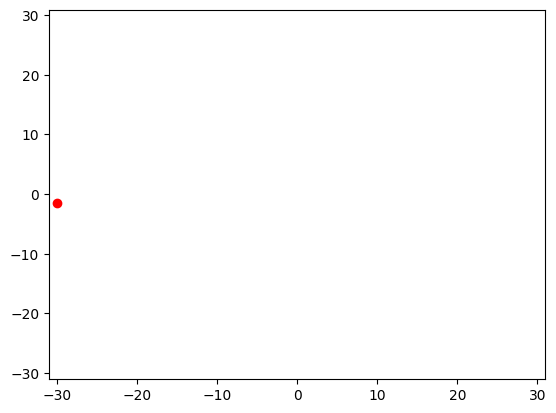

In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


df = pd.read_csv("cones.csv")

centerx=df["x"].mean()
centery=df["y"].mean()
blue_df= df[df["color"]=='blue'].copy()   
yellow_df= df[df["color"]=='yellow'].copy() 

blue_df["angle"] = np.arctan2(blue_df['y']-centery,blue_df['x']-centerx)
yellow_df["angle"] = np.arctan2(yellow_df['y']-centery,yellow_df['x']-centerx)

blue_df=blue_df.sort_values(by='angle').reset_index(drop=True).drop(columns='color')
yellow_df=yellow_df.sort_values(by='angle').reset_index(drop=True).drop(columns='color')

red_df = (blue_df+ yellow_df)/2

fig, ax = plt.subplots()
ax.set_xlim(red_df['x'].min()-1,red_df['x'].max()+1)
ax.set_ylim(red_df['y'].min()-1,red_df['y'].max()+1)


particle, = ax.plot([], [], 'ro')

def update(frame):
    particle.set_data([red_df["x"].iloc[frame]], [red_df["y"].iloc[frame]])
    return particle,

ani = FuncAnimation(
    fig,
    update,
    frames=len(red_df),
    interval=100
)
HTML(ani.to_jshtml())

